In [321]:
import tensorflow as tf
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import os
import random
import pickle
import time
from datetime import datetime
import re
import scipy

from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output

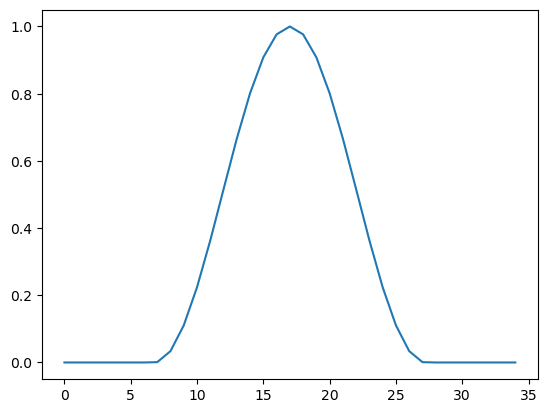

In [352]:
def ramp(a, b, t, half_wave=False):
    assert a <= b
    if t <= a:
        return 0.
    elif t >= b:
        return 0. if half_wave else 1.
    else:
        return 0.5 * (1. - np.cos((2. if half_wave else 1.)*np.pi * (t - a)/(b - a)))

ramp = np.vectorize(ramp)

plt.plot(
        ramp(0.2, 0.8, np.linspace(0.0, 1.0, 35), half_wave=True)
)

In [334]:
LAMBDA_0S = [0.0, 0.02] * 10

LABELLED_BATCH_SIZE = 32
UNLABELLED_BATCH_SIZE = 32
SHUFFLE_SIZE = 512
IMG_SIZE = (128, 128)   # (H, W)
MAX_STEPS = 2048

NUM_VAL_VOLS = 64
NUM_LABELLED_VOLS = 3
MAX_LABELLED_NUM = 256
MAX_VAL_NUM = 512

LAMBDAS = (LAMBDA_0S[0] * ramp(0.2, 0.4, np.linspace(0.0, 1.0, 30))).astype(np.float32)
BLIND_PROB = 0.0

SEED = random.randint(0,9999)

print(f"Tensorflow version: {tf.version.VERSION}")

Tensorflow version: 2.19.0


In [335]:
with open('nonempty-paths-vols.pkl', 'rb') as file:
    vols = pickle.load(file)
    
vols.sort()

rng = random.Random(SEED)

rng.shuffle(vols)
val_vols = vols[-NUM_VAL_VOLS:]
train_vols = vols[:-NUM_VAL_VOLS]
labelled_vols = train_vols[-NUM_LABELLED_VOLS:]
unlabelled_vols = train_vols[:-NUM_LABELLED_VOLS]

val_paths = [x for vol in val_vols for x in vol]
labelled_paths = [x for vol in labelled_vols for x in vol]
rng.shuffle(labelled_paths)
labelled_paths = labelled_paths[:MAX_LABELLED_NUM]
unlabelled_paths = [x for vol in unlabelled_vols for x in vol]

rng.shuffle(val_paths)
val_paths = val_paths[:MAX_VAL_NUM]
rng.shuffle(labelled_paths)
rng.shuffle(unlabelled_paths)

print(f"Training set: {len(labelled_paths)} labelled, {len(unlabelled_paths)} unlabelled\nValidation set: {len(val_paths)}")

Training set: 133 labelled, 14390 unlabelled
Validation set: 512


In [325]:
# THANK YOU CHATGPT FOR WRITING THIS 🙏🙏🙏🙏
# I'M GLAD THE AI UNDERSTANDS APPLE METAL GPU
# PLEASE DON'T TAKE MY JOB THO
# TODO: try out deterministic blinding
def get_dataset(paths, img_size=IMG_SIZE, shuffle_buf=None):
    """H5 → (image, mask) with TF ops; minimal py bridge, stable on Apple Metal.
    If specified (not None), `peekaboo` will randomly hide all channels except one with probability `peekaboo`"""

    # --- tiny py bridge: read raw arrays from .h5 ---
    def _read_h5(path):
        path = path.numpy().decode("utf-8")
        with h5.File(path, "r") as f:
            img = f["image"][:, :, 0:3]                      # (H,W,3)
            msk = f["mask"][...].max(-1)                     # (H,W) foreground>0
            
        img = img.astype("float32")                          # (H,W,3)
        # add channel dim here so TF ops know ranks
        msk = (msk > 0).astype("int32")[..., np.newaxis]     # (H,W,1) 0/1
        return img, msk

    def _py_reader(path):
        img, msk = tf.py_function(_read_h5, [path], [tf.float32, tf.int32])
        # set static ranks so later ops don’t guess and crash
        img.set_shape([None, None, 3])
        msk.set_shape([None, None, 1])
        return img, msk

    # --- pure TF preprocessing (GPU/Metal friendly) ---
    def _preprocess(img, msk):
        # image: (H,W,1) -> RGB -> resize -> per-image min-max normalize
        img = tf.image.resize(img, img_size)                           # (H,W,3)
        minv = tf.reduce_min(img, axis=[0,1,2])                        # scalar
        maxv = tf.reduce_max(img, axis=[0,1,2])                        # scalar
        img = (img - minv) / (maxv - minv + 1e-8)

        # mask: keep integer class ids, resize w/ nearest, keep channel dim
        msk = tf.image.resize(msk, img_size, method="nearest")         # (h,w,1)
        msk = tf.cast(msk, tf.int32)
        msk = tf.ensure_shape(msk, (img_size[0], img_size[1], 1))
        return img, msk

    opts = tf.data.Options()
    opts.deterministic = False  # let tf parallelize safely

    ds = tf.data.Dataset.from_tensor_slices(paths).with_options(opts)
    ds = ds.map(_py_reader, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle_buf:
        ds = ds.shuffle(shuffle_buf)

    return ds

In [326]:
val_ds = get_dataset(val_paths)
labelled_ds = get_dataset(labelled_paths, shuffle_buf=SHUFFLE_SIZE)
unlabelled_ds = get_dataset(unlabelled_paths, shuffle_buf=SHUFFLE_SIZE)
# train_ds = tf.data.Dataset.zip((labelled_ds.repeat(), unlabelled_ds))

# train_batches = (
#     train_ds
#     .cache()
#     .batch(BATCH_SIZE)
#     .repeat()
#     .prefetch(buffer_size=tf.data.AUTOTUNE)
# )


labelled_batches = (
    labelled_ds
    .cache()
    .repeat()
    .shuffle(SHUFFLE_SIZE)
    .batch(LABELLED_BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

unlabelled_batches = (
    unlabelled_ds
    .cache()
    .repeat()
    .shuffle(SHUFFLE_SIZE)
    .batch(UNLABELLED_BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

val_batches = (
    val_ds
    .cache()
    .batch(64)
    .prefetch(buffer_size=tf.data.AUTOTUNE))

In [327]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

In [478]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False, weights=None)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False

up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # Downsampling through the model
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = tf.keras.layers.Concatenate()
        x = concat([x, skip])

    # This is the last layer of the model
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2,
        padding='same')  #64x64 -> 128x128

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

In [329]:
OUTPUT_CLASSES = 2
model = unet_model(output_channels=OUTPUT_CLASSES)

def create_mask(pred_mask, index=0):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[index]

def show_predictions(dataset, num=1, num_in_batch=0):
  for image, mask in dataset.take(num):
    pred_mask = model.predict(image)
    display([image[num_in_batch], mask[num_in_batch], create_mask(pred_mask, num_in_batch)])

In [330]:
# Courtesy of ChatGPT
class DiceCoefficient(tf.keras.metrics.Metric):
    def __init__(self, name="dice_coefficient", smooth=1e-6, **kwargs):
        super(DiceCoefficient, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.dice_sum = self.add_weight(name="dice_sum", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # probs → softmax (multi-class) or sigmoid (binary)
        y_pred = tf.nn.softmax(y_pred, axis=-1)

        # one-hot encode labels if sparse
        if y_true.dtype.is_integer:
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

        # flatten
        y_true = tf.reshape(y_true, [-1, tf.shape(y_pred)[-1]])
        y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

        intersection = tf.reduce_sum(y_true * y_pred, axis=0)
        union = tf.reduce_sum(y_true, axis=0) + tf.reduce_sum(y_pred, axis=0)

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice = tf.reduce_mean(dice)

        self.dice_sum.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.dice_sum / self.count

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

In [331]:
class Logger:
    def __init__(self, filepath, hyperparameters):
        self.filepath = filepath
        self.hyperparameters = hyperparameters
        self.epoch = 0
        with open(self.filepath, "a") as file:
            for var, val in self.hyperparameters.items():
                file.write(f"{var}: {val}\n")
    
    def log_line(self, msg):
        with open(self.filepath, "a") as file:
            file.write(msg + "\n")
    
    def next_epoch(self):
        with open(self.filepath, "a") as file:
            file.write(f"Epoch {self.epoch} started\n")
        self.epoch += 1
    
    def update_training_log(self, step, sec_per_step, stats):
        with open(self.filepath, "a") as file:
            file.write(f"  Step: {step} ({sec_per_step} s/step):\n")
            for stat, val in stats.items():
                file.write(f"    {stat}: {val}\n")

In [ ]:
MAX_EPOCHS = 1
labelled_train_length = len(labelled_paths)
steps_per_epoch = labelled_train_length // LABELLED_BATCH_SIZE

# Customised training loop
# supervised_loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)      # maybe try DICE?
# unsupervised_loss_func_inner = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
dice_metric = DiceCoefficient()

@tf.function
def supervised_loss_func(y_true, y_pred):
    y_pred_softmax = tf.nn.softmax(y_pred)
    cce = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred_softmax)
    dice = tf.keras.losses.Dice()(y_true, y_pred_softmax)
    
    return cce + 0.0 * dice

# Thx ChatGPT - modified to not use KL divergence loss (no thx ChatGPT)
@tf.function
def unsupervised_loss_func(xu_batch, model, num_channels=3):
    preds = []
    for ch in range(num_channels):
        # mask all but one channel
        mask = tf.one_hot(ch, num_channels)  # shape (num_channels,)
        mask = tf.reshape(mask, (1,1,1,num_channels))
        x_masked = xu_batch * mask  # zero out others

        # forward pass -> logits
        p = model(x_masked, training=True)  # (B,H,W,C)
        # softmax so we’re comparing probs not raw logits
        p = tf.nn.softmax(p, axis=-1)
        preds.append(p)

    preds = tf.stack(preds, axis=0)  # (num_channels, B,H,W,C)

    # average prediction = "reference"
    ref = tf.stop_gradient(tf.reduce_mean(preds, axis=0))  # (B,H,W,C)

    # consistency loss TODO: try MSE, KL (learn what this means), Dice
    loss = 0.
    for p in tf.unstack(preds, axis=0):
        loss += (
            tf.keras.losses.Dice()(ref, p)
        )
    loss /= num_channels
    return loss

# Another chatGPT tensorflow image manipulation magic W
@tf.function
def blind_batch(batch, p):
    batch_size, _, _, channels = batch.shape
    # Randomly choose channel indices for each image
    rand_channels = tf.random.uniform(
        shape=[batch_size], 
        minval=0, 
        maxval=channels, 
        dtype=tf.int32
    )

    one_hot = tf.one_hot(rand_channels, channels, on_value=0., off_value=1.)  # [batch, C]
    channel_mask = tf.reshape(one_hot, [batch_size, 1, 1, channels])
    channel_mask = tf.cast(channel_mask, batch.dtype)

    # Random Bernoulli to decide if we apply masking
    apply_mask = tf.cast(
        tf.random.uniform([batch_size, 1, 1, 1]) < p, 
        batch.dtype
    )
    res = batch * (1 - apply_mask) + batch * channel_mask * apply_mask

    return res

# TODO: Fix bug with validation loss
@tf.function
def step(xl_batch, yl_batch, xu_batch, unsupervised_lambda):
    # Calculate loss
    with tf.GradientTape() as tape:
        xl_blinded = blind_batch(xl_batch, BLIND_PROB)
        yl_pred = model(xl_blinded, training=True)
        supervised_loss = supervised_loss_func(yl_batch, yl_pred)
        unsupervised_loss = unsupervised_loss_func(xu_batch, model)
        loss = supervised_loss + unsupervised_lambda * unsupervised_loss
        
    # Update gradients
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    
    return supervised_loss, unsupervised_loss

@tf.function
def val_step(x_batch, y_batch, val_metric):
    y = model(x_batch, training=False)
    val_metric.update_state(y_batch, y)
    return supervised_loss_func(y_batch, y)

@tf.function
def update_metric(metric):
    validation_start = time.perf_counter()
    metric.reset_state()
    avg_loss = 0.
    last_loss= -1.
    n = 0.
    for x_batch_val, y_batch_val in val_batches: # type: ignore
        last_loss = val_step(x_batch_val, y_batch_val, metric) # type: ignore
        avg_loss += last_loss # type: ignore
        n += 1.
        
    avg_loss /= n
    metric_val = metric.result()
    
    return (metric_val, {
        "Validation Loss": avg_loss,
        "Last Val Loss": last_loss,
        "DICE Validation": metric_val,
        "Validation Time (s)": time.perf_counter() - validation_start,
        "Num Val Batches": n,
    })

In [333]:
usls = []
sls = []
dice_scores = []

LOG_PATH = 'training-logs'

hyperparams = {
    "LABELLED_BATCH_SIZE": LABELLED_BATCH_SIZE,
    "UNLABELLED_BATCH_SIZE": UNLABELLED_BATCH_SIZE,
    "SHUFFLE_SIZE": SHUFFLE_SIZE,
    "IMG_SIZE": IMG_SIZE,
    "NUM_LABELLED_VOLS": NUM_LABELLED_VOLS,
    "NUM_VAL_VOLS": NUM_VAL_VOLS,
    "MAX_VAL_NUM": MAX_VAL_NUM,
    "LAMBDAS": LAMBDAS,
    "BLIND_PROB": BLIND_PROB,
    "SEED": SEED,
    "LABELLED SLICES": len(labelled_paths),
    "UNLABELLED SLICES": len(unlabelled_paths),
    "VALIDATION SLICES": len(val_paths),
}
logger_path = os.path.join(LOG_PATH, datetime.now().strftime("%Y-%m-%d %H-%M-%S"))
logger = Logger(logger_path+".txt", hyperparams)

# Main training loop
train_start = time.perf_counter()
for epoch, unsupervised_lambda in enumerate(LAMBDAS):
    epoch_start = time.perf_counter()
    logger.next_epoch()
    
    # Perform training steps
    step_time_sum = 0
    labelled_iter = iter(labelled_batches)
    unlabelled_iter = iter(unlabelled_batches)
    for n_step in range(steps_per_epoch):
        step_start = time.perf_counter()

        (xl_batch, yl_batch) = next(labelled_iter)
        (xu_batch, _) = next(unlabelled_iter)
    # for n_step, ((xl_batch, yl_batch), (xu_batch, _)) in enumerate(train_batches.take(steps_per_epoch)):
        [sl, usl] = step(xl_batch, yl_batch, xu_batch, unsupervised_lambda=unsupervised_lambda) # type: ignore
        usls.append(usl)
        sls.append(sl)
        step_time_sum += time.perf_counter() - step_start

        if n_step % 8 == 0:
            [metric_val, stats] = update_metric(dice_metric) # type: ignore
            dice_scores.append(metric_val)
            stats.update({
                "Training Supervised Loss": sl,
                "Training Unsupervised Loss": usl
            })
            logger.update_training_log(n_step, step_time_sum / (n_step+1), stats)

logger.log_line(f"Training done in {time.perf_counter() - train_start:.02f}s.")
logger.log_line(f"Supervised losses: {[x.numpy() for x in sls]}\nUnsupervised losses: {[x.numpy() for x in usls]}")

with open(logger_path+".pkl", "wb") as file:
    pickle.dump({
        "dice": dice_scores,
        "sls": sls,
        "usls": usls,
        "lambdas": LAMBDAS,
        "labelled_paths": labelled_paths,
        "unlabelled_paths": unlabelled_paths,
        "seed": SEED,
        "dataset_sizes": {
            "labelled": len(labelled_paths),
            "unlabelled": len(unlabelled_paths),
            "validation": len(val_paths)
        }
    }, file)

2025-09-29 16:35:40.274306: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-29 16:35:55.140125: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-29 16:36:11.617116: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. I

KeyboardInterrupt: 

In [ ]:
def plot_dice(ax: Axes, dices, num_epochs, label=None, c=None, fmt='.-'):
    # x = np.array(range(len(dices)))
    ax.plot(np.linspace(0,num_epochs,len(dices)), dices, fmt, label=label, c=c)
    ax.set_title("Validation Dice During Training")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Dice Score")

def plot_losses(ax: Axes, sls, usls, label='', c_sup=None, c_unsup=None):
    ax.plot(usls, label=('Unsupervised Loss ' + label), c=c_unsup)
    ax.plot(sls, label=('Supervised Loss ' + label), c=c_sup)
    ax.set_title("Losses")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Loss")
    
def plot_lambdas(ax: Axes, lambdas, label=None, c=None):
    ax.plot(lambdas, label=label)
    ax.set_title("SSL $\\lambda$ Values")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("$\\lambda$")

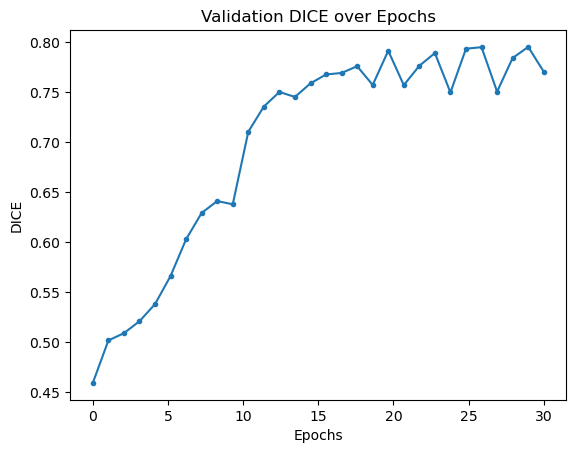

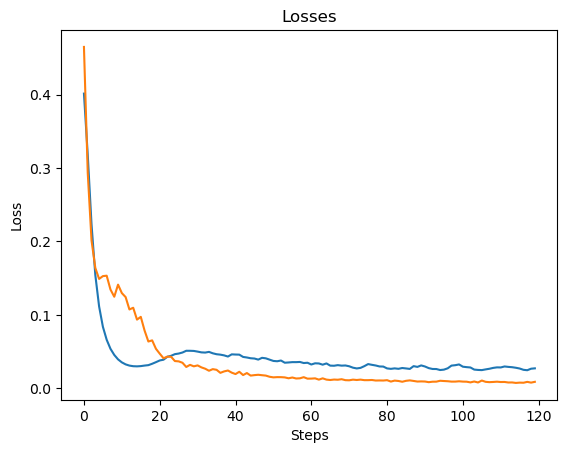

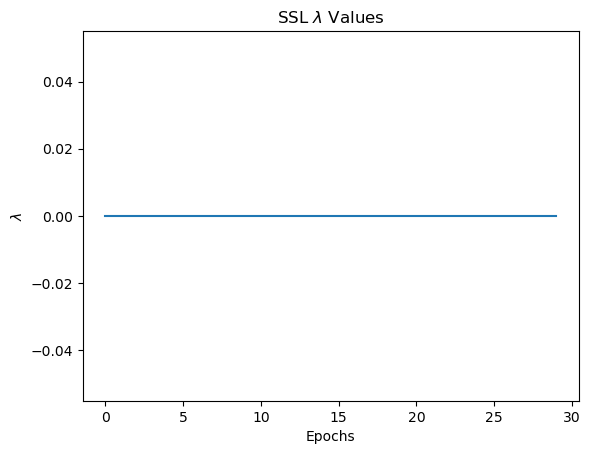

In [ ]:
dice_plot = plt.figure().add_subplot()
losses_plot = plt.figure().add_subplot()
lambdas_plot = plt.figure().add_subplot()

plot_dice(dice_plot, dice_scores, len(LAMBDAS))
plot_losses(losses_plot, sls, usls, label='losses')
plot_lambdas(lambdas_plot, LAMBDAS)

top nulls (concat'd): [0.65573055 0.7372719  0.7138171  0.79467386 0.78619367 0.77618426
 0.78729415 0.7485541  0.7670747  0.6811894  0.7746707 ]
top ssls (concat'd): [0.714934   0.70921165 0.753189   0.79915524 0.83766663 0.8007046
 0.8208509  0.8531866  0.8245596  0.79979223 0.7690836  0.8224297 ]
mean best null: 0.748 +/- 0.014
mean best ssl: 0.792 +/- 0.013
p-value: 0.0105327569


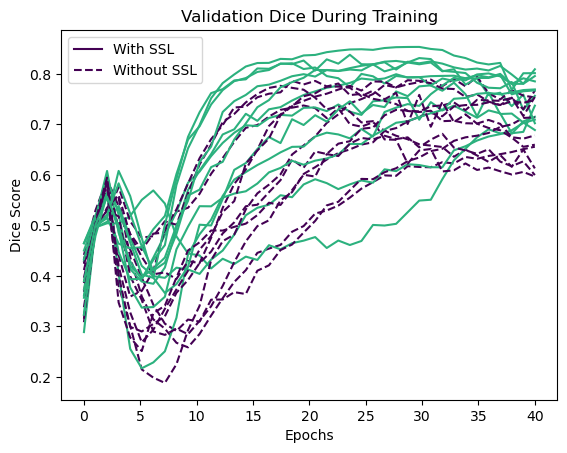

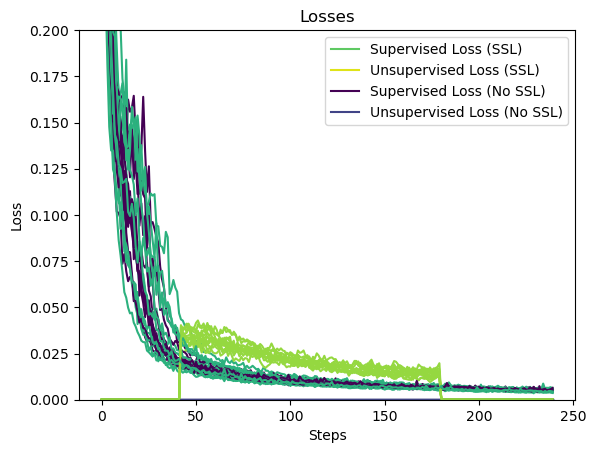

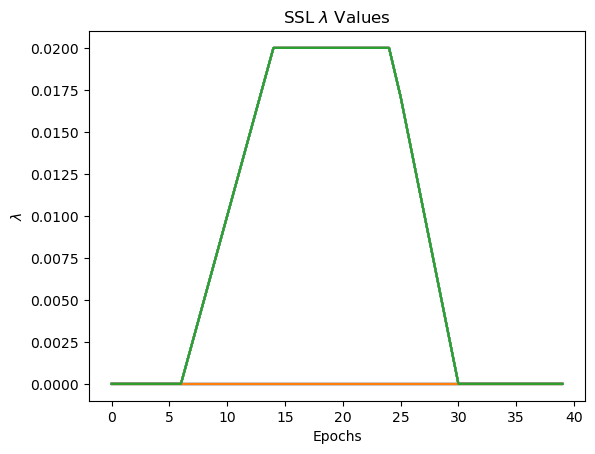

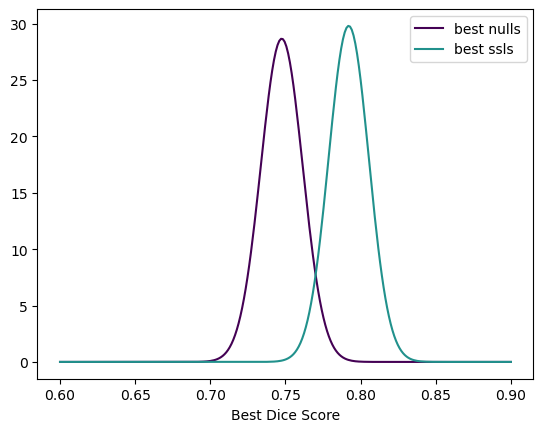

In [532]:
ANALYSE_PATH = 'analyse-pkls'

dice_plot = plt.figure().add_subplot()
losses_plot = plt.figure().add_subplot()
lambdas_plot = plt.figure().add_subplot()
cmap = plt.colormaps['viridis']

max_null = []
max_ssl = []

def max_n(arr, n):
    return np.sort(arr)[-n:]

for path in os.listdir(ANALYSE_PATH):
    with open(os.path.join(ANALYSE_PATH, path), 'rb') as file:
        data = pickle.load(file)
        
    
    col_t = data['lambdas'].mean() * 75
    num_epochs = len(data['lambdas'])
    fmt = '--' if col_t < 1e-6 else '-'
    plot_dice(dice_plot, data['dice'], num_epochs, c=cmap(col_t), label=path, fmt=fmt)
    plot_losses(losses_plot, data['sls'], data['usls'], label=path, c_sup=cmap(col_t), c_unsup = cmap(col_t + 0.2))
    plot_lambdas(lambdas_plot, data['lambdas'], label=path, c=cmap(0.))
    
    # null will have col_t = 0 (maybe floating point error)
    (max_null if col_t < 1e-5 else max_ssl).append(max_n(data['dice'], 1))

max_null = np.array(max_null).flatten()
max_ssl = np.array(max_ssl).flatten()
print(f"top nulls: {max_null}\ntop ssls: {max_ssl}")

best_null = (np.mean(max_null), np.std(max_null, ddof=1)/np.sqrt(len(max_null)))
best_ssl = (np.mean(max_ssl), np.std(max_ssl, ddof=1)/np.sqrt(len(max_ssl)))

z_score = (best_ssl[0] - best_null[0]) / np.sqrt(best_null[1]**2 + best_ssl[1]**2)
p_value = scipy.stats.norm.sf(abs(z_score))
print(f"mean best null: {best_null[0]:.03f} +/- {best_null[1]:.03f}\nmean best ssl: {best_ssl[0]:.03f} +/- {best_ssl[1]:.03f}\np-value: {p_value:.010f}")


ssl_handle, = dice_plot.plot([], [], '-', c=cmap(0.), label='With SSL')
null_handle, = dice_plot.plot([], [], '--', c=cmap(0.), label='Without SSL')
dice_plot.legend(handles=[ssl_handle, null_handle])
# dice_plot.legend()
# dice_plot.set_ylim((0.75, 0.85))

ssl_sl_handle, = dice_plot.plot([], c=cmap(0.75), label='Supervised Loss (SSL)')
ssl_usl_handle, = dice_plot.plot([], c=cmap(0.95), label='Unsupervised Loss (SSL)')
null_sl_handle, = dice_plot.plot([], c=cmap(0.0), label='Supervised Loss (No SSL)')
null_usl_handle, = dice_plot.plot([], c=cmap(0.2), label='Unsupervised Loss (No SSL)')
losses_plot.legend(handles=[ssl_sl_handle, ssl_usl_handle, null_sl_handle, null_usl_handle])
losses_plot.set_ylim((0., 0.2))

plt.show()

x = np.linspace(0.6, 0.9, 256)
plt.plot(x, scipy.stats.norm.pdf(x, loc=best_null[0], scale=best_null[1]), label='best nulls', c=cmap(0.0))
plt.plot(x, scipy.stats.norm.pdf(x, loc=best_ssl[0], scale=best_ssl[1]), label='best ssls', c=cmap(0.5))
plt.xlabel("Best Dice Score")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


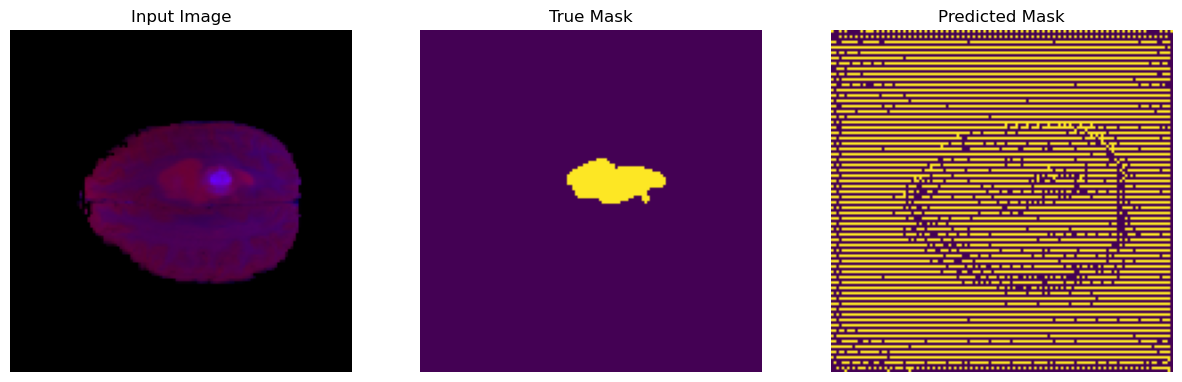

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


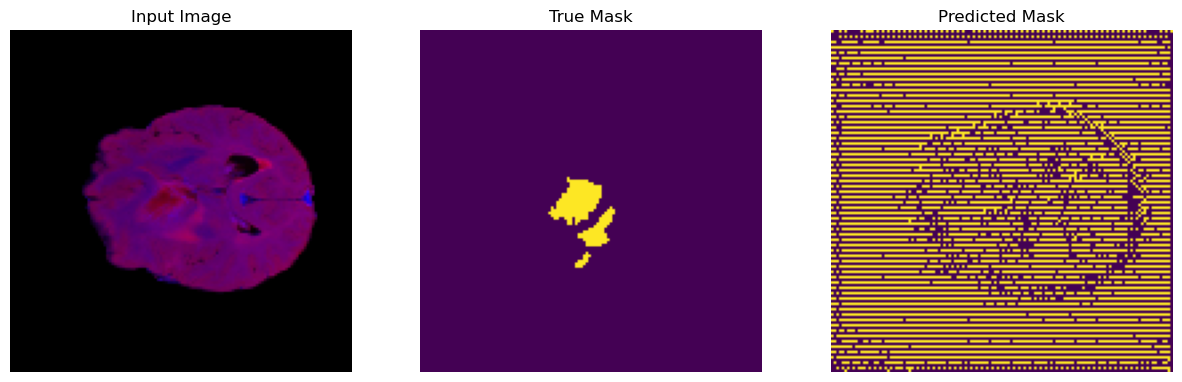

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


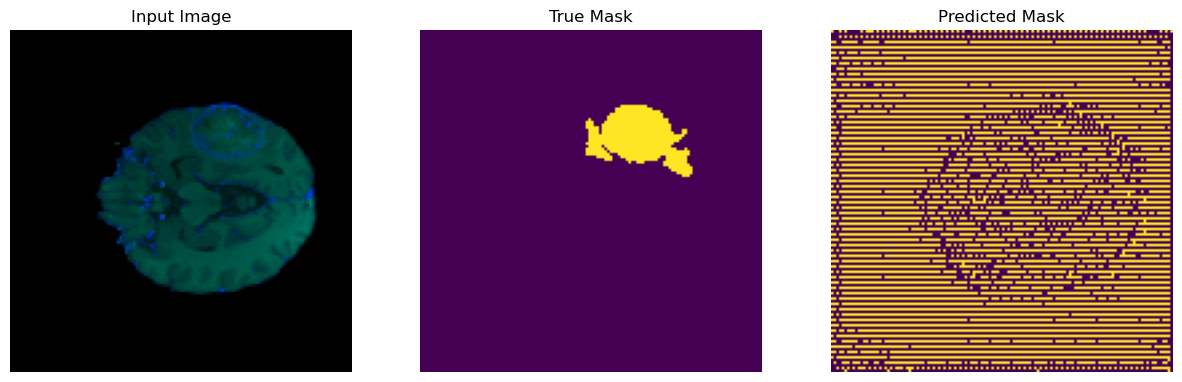

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


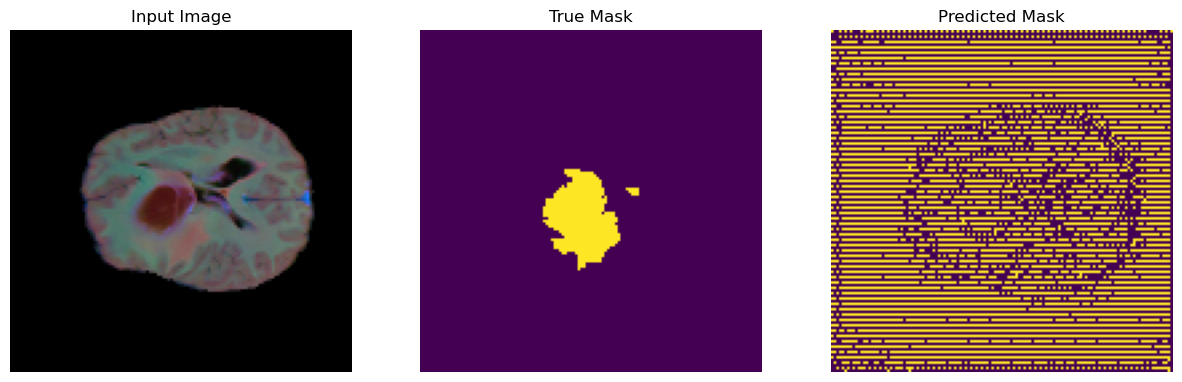

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


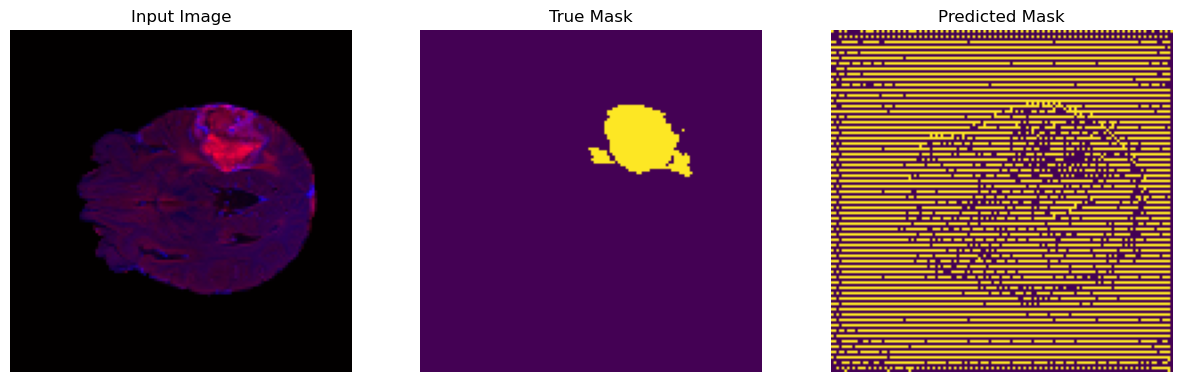

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


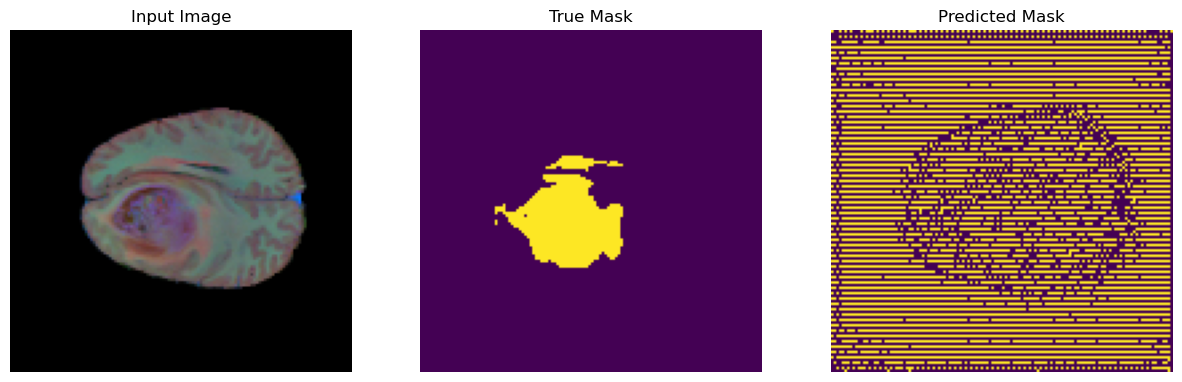

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


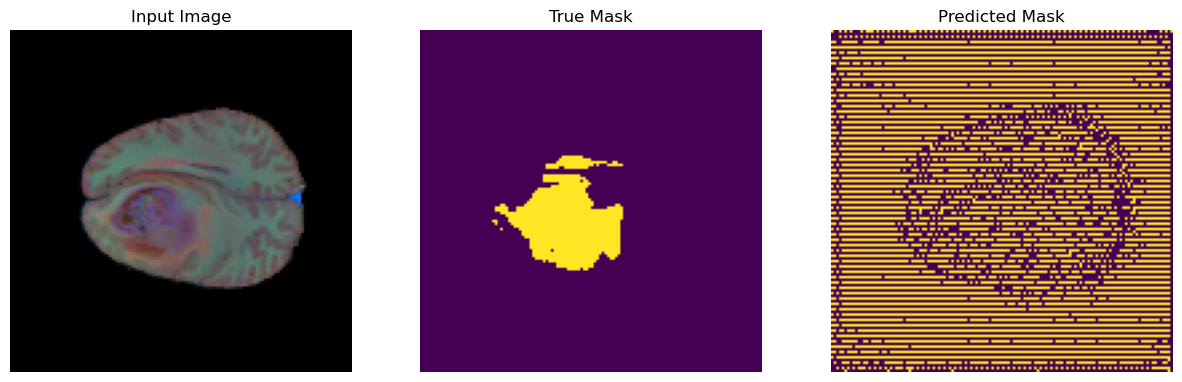

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


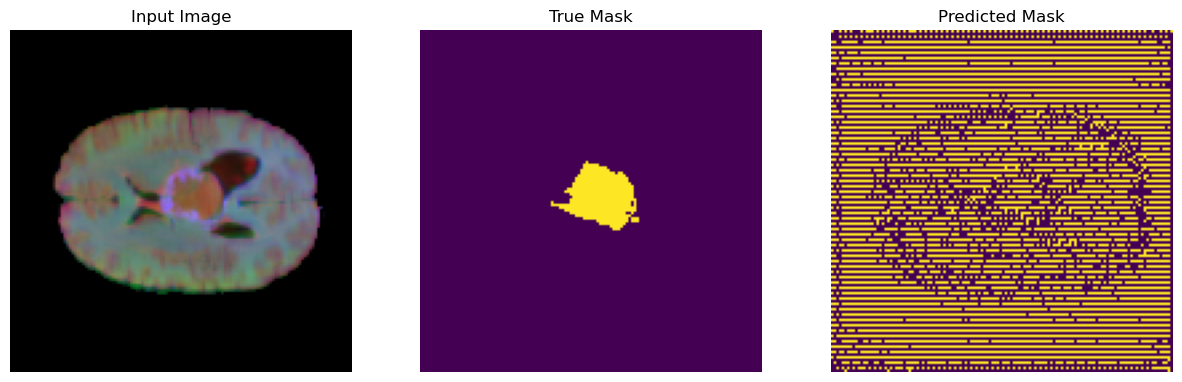

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


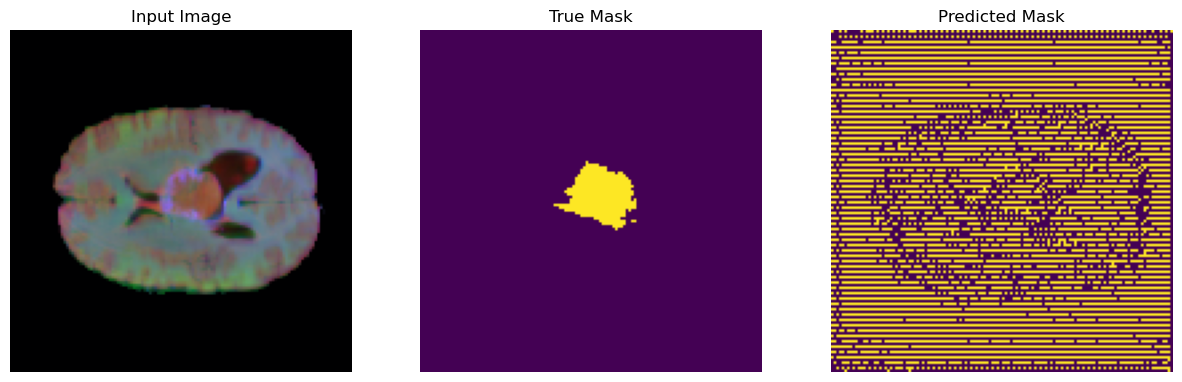

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


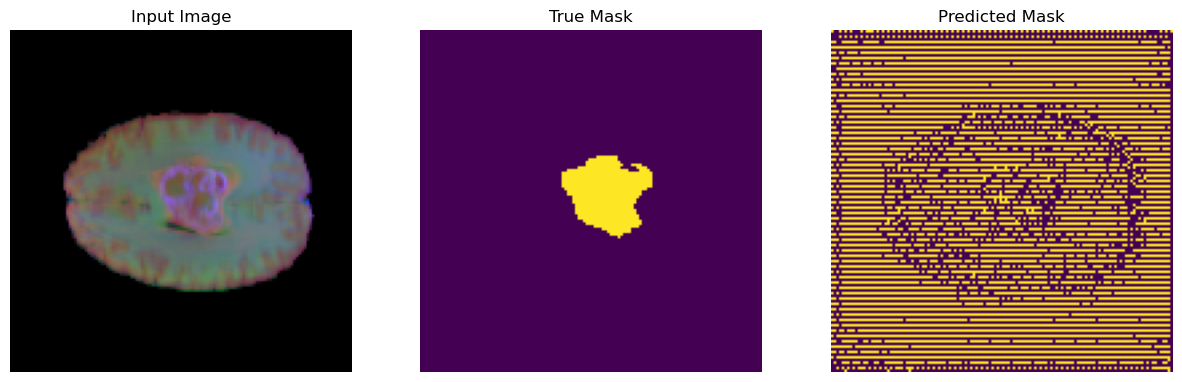

In [479]:

for image, mask in labelled_batches.take(10):
    blinded = blind_batch(image, 0.5)
    pred_mask = model.predict(blinded)
    display([blinded[0], mask[0], create_mask(pred_mask, 0)])


<img src="shrimple.gif">

40


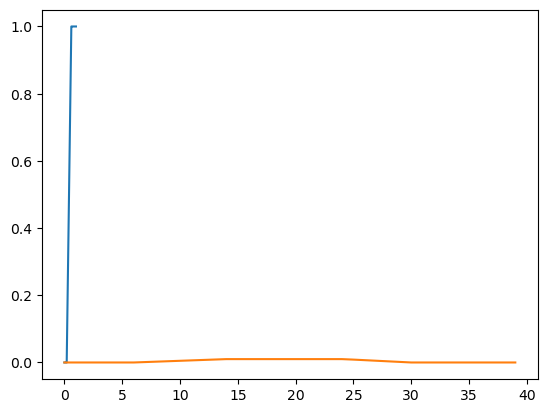

In [508]:
def lin_ramp(x1,y1,x2,y2,t):
    assert x1 <= x2
    if t < x1:
        return y1
    elif t > x2:
        return y2
    return np.interp(t, [x1,x2], [y1,y2])

lin_ramp = np.vectorize(lin_ramp)

ts = np.linspace(0.0, 1.0, 101)
plt.plot(ts, lin_ramp(0.2,0.0,0.6,1.0,ts))

ls = 0.01 * np.concat((
        lin_ramp(0.15, 0.0, 0.35, 1.0, np.linspace(0.0, 0.5, 21)),
        lin_ramp(0.67, 1.0, 0.80, 0.0, np.linspace(0.6, 1.0, 19))
    ))
plt.plot(ls)